In [156]:
from pathlib import Path
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

In [157]:
# paths and constants
DATA_DIR = Path('../data/keypoints_1')
OUT_DIR = Path('../data/processed')
LABELS_CSV = Path('../data/hp.csv')
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Load Data

In [158]:
def load_labels_mapping():
    if not LABELS_CSV.exists():
        print(f"Warning: {LABELS_CSV} not found")
        return None
    
    labels_df = pd.read_csv(LABELS_CSV)
    mapping = {}
    for _, row in labels_df.iterrows():
        video_name = f"{row['division']}_{row['id']}"
        mapping[video_name] = row['labels']
    return mapping

In [159]:
def find_videos(root=DATA_DIR):
    records = []
    if not root.exists():
        raise FileNotFoundError(f"Data dir not found: {root}")
    
    labels_mapping = load_labels_mapping()
    
    for label_dir in sorted(root.iterdir()):
        if not label_dir.is_dir():
            continue
        division = label_dir.name
        
        for video_dir in sorted(label_dir.iterdir()):
            if not video_dir.is_dir():
                continue
            
            np_path = video_dir / 'keypoints.npy'
            json_path = video_dir / 'keypoints.json'
            if not np_path.exists():
                continue
            
            video_name = video_dir.name
            trick_label = labels_mapping.get(video_name, division) if labels_mapping else division
            
            records.append({
                'label': trick_label,
                'division': division,
                'video': video_name,
                'np_path': np_path,
                'json_path': json_path
            })
    
    return pd.DataFrame(records)

In [160]:
def load_keypoints(np_path: Path):
    arr = np.load(np_path)
    if arr.ndim != 3: 
        raise ValueError(f"Unexpected shape {np_path}: {arr.shape}")
    return arr.astype(np.float32)

## Preprocessing Functions

In [161]:
def interpolate_missing(arr, visibility_threshold=0.1):
    # fill in missing keypoints using interpolation
    out = arr.copy()
    T = out.shape[0]
    
    for lm in range(out.shape[1]):
        vis = out[:, lm, 3]
        bad = vis < visibility_threshold
        if bad.all():
            continue
        
        for d in range(3):
            vals = out[:, lm, d].astype(float)
            vals[bad] = np.nan
            s = pd.Series(vals)
            vals_filled = s.interpolate(limit_direction='both').bfill().ffill().values
            out[:, lm, d] = vals_filled.astype(np.float32)
    
    return out

In [162]:
def torso_scale_single(lm):
    # get torso length for normalization
    left_sh = lm[11][:2]
    right_sh = lm[12][:2]
    left_hip = lm[23][:2]
    right_hip = lm[24][:2]
    mid_sh = (left_sh + right_sh) / 2.0
    mid_hip = (left_hip + right_hip) / 2.0
    d = np.linalg.norm(mid_sh - mid_hip)
    return max(d, 1e-6)

In [163]:
def normalize_by_torso(arr):
    # normalize positions relative to hip center and torso length
    out = arr.copy()
    for t in range(out.shape[0]):
        lm = out[t]
        hip_center = (lm[23][:2] + lm[24][:2]) / 2.0
        scale = torso_scale_single(lm)
        out[t, :, :2] = (lm[:, :2] - hip_center) / scale
    return out

In [164]:
def pad_or_truncate(arr, target_len=64, strategy='center'):
    T = arr.shape[0]
    if T == target_len:
        return arr
    if T > target_len:
        if strategy == 'center':
            start = max(0, (T - target_len) // 2)
            return arr[start:start+target_len]
        return arr[:target_len]
    
    pad = np.zeros((target_len - T, arr.shape[1], arr.shape[2]), dtype=arr.dtype)
    return np.concatenate([arr, pad], axis=0)

In [165]:
def angle_at(a, b, c):
    # compute angle at point b formed by points a-b-c
    ba = a - b
    bc = c - b
    lena = np.linalg.norm(ba)
    lenb = np.linalg.norm(bc)
    if lena < 1e-6 or lenb < 1e-6:
        return 0.0
    cosang = np.dot(ba, bc) / (lena * lenb)
    cosang = np.clip(cosang, -1.0, 1.0)
    return math.acos(cosang)

## Feature Extraction

In [166]:
ANGLE_TRIPLETS = [(11, 13, 15), (12, 14, 16), (23, 25, 27), (24, 26, 28)]
def compute_frame_features(seq):
    # extract features from keypoint sequence
    T = seq.shape[0]
    flat = seq[:, :, :3].reshape(T, -1)
    
    # joint angles
    angles = np.zeros((T, len(ANGLE_TRIPLETS)), dtype=np.float32)
    for t in range(T):
        for i, (a, b, c) in enumerate(ANGLE_TRIPLETS):
            angles[t, i] = angle_at(seq[t, a, :2], seq[t, b, :2], seq[t, c, :2])
    
    # pairwise distances between key joints
    important = [11, 12, 23, 24, 13, 14, 25, 26]
    pdists = []
    for t in range(T):
        coords = seq[t, important, :2]
        dists = []
        for i in range(coords.shape[0]):
            for j in range(i+1, coords.shape[0]):
                dists.append(np.linalg.norm(coords[i] - coords[j]))
        pdists.append(dists)
    pdists = np.array(pdists)
    
    # velocity
    vel = np.vstack((np.zeros((1, flat.shape[1])), np.diff(flat, axis=0)))
    
    feats = np.concatenate([flat, angles, pdists, vel], axis=1)
    return feats

In [167]:
def aggregate_video_features(seq, target_len=64):
    # preprocess and aggregate features for entire video
    seq = interpolate_missing(seq)
    seq = normalize_by_torso(seq)
    seq = pad_or_truncate(seq, target_len=target_len)
    
    frame_feats = compute_frame_features(seq)
    mean = frame_feats.mean(axis=0)
    std = frame_feats.std(axis=0)
    
    return np.concatenate([mean, std])

In [168]:
def build_aggregated_dataset(index_df, sample_limit=None, target_len=64):
    rows = []
    X = []
    y = []
    
    subset = index_df.sample(min(len(index_df), sample_limit), random_state=0) if sample_limit is not None else index_df
    
    for _, r in subset.iterrows():
        seq = load_keypoints(r['np_path'])
        vec = aggregate_video_features(seq, target_len=target_len)
        X.append(vec)
        y.append(r['label'])
        rows.append({
            'label': r['label'],
            'division': r.get('division', ''),
            'video': r['video'],
            'np_path': str(r['np_path'])
        })
    
    return np.array(X), np.array(y), pd.DataFrame(rows)

In [169]:
def do_dimensionality_reduction(X, n_pca=10):
    n_samples, n_features = X.shape
    print(f'Running PCA -> t-SNE (n_samples={n_samples}, n_features={n_features})...')

    pca_components = max(2, min(n_pca, n_samples, n_features))
    pca = PCA(n_components=pca_components, random_state=0)
    X_pca = pca.fit_transform(X)

    if n_samples < 3:
        print('Too few samples for t-SNE (need >=3). Returning PCA only.')
        return {'pca': X_pca}

    perplexity = min(30, max(2, (n_samples - 1) // 3))
    perplexity = min(perplexity, n_samples - 1)
    
    try:
        tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate='auto', init='pca', random_state=0)
        X_tsne = tsne.fit_transform(X_pca[:, :pca_components])
    except Exception as exc:
        print('t-SNE failed:', exc)
        X_tsne = None
    
    return {'pca': X_pca, 'tsne': X_tsne}

In [170]:
def clustering_kmeans(X, k_range=range(2, 9)):
    inertias = []
    sils = []
    models = {}
    
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=0).fit(X)
        labels = km.labels_
        models[k] = km
        
        try:
            sil = silhouette_score(X, labels)
        except Exception:
            sil = np.nan
        
        inertias.append(km.inertia_)
        sils.append(sil)
    
    return models, list(k_range), inertias, sils


## Run Analysis

In [171]:
# load videos
df = find_videos()
print(f'Found {len(df)} videos\n')
print('Label distribution:')
print(df['label'].value_counts())

Found 16 videos

Label distribution:
label
sugar_tag     9
sugar_push    7
Name: count, dtype: int64


In [172]:
# build dataset
X, y, meta = build_aggregated_dataset(df, target_len=64)
print(f'Dataset shape: {X.shape}')

# standardize
Xs = StandardScaler().fit_transform(X)

Dataset shape: (16, 460)


In [173]:
# dimensionality reduction
emb = do_dimensionality_reduction(X)

if 'tsne' in emb and emb['tsne'] is not None:
    emb_plot = emb['tsne']
    method = 't-SNE'
else:
    emb_plot = emb['pca'][:, :2]
    method = 'PCA'

print(f'Using {method} for visualization')

Running PCA -> t-SNE (n_samples=16, n_features=460)...
Using t-SNE for visualization


### Visualization 1: By Trick Type

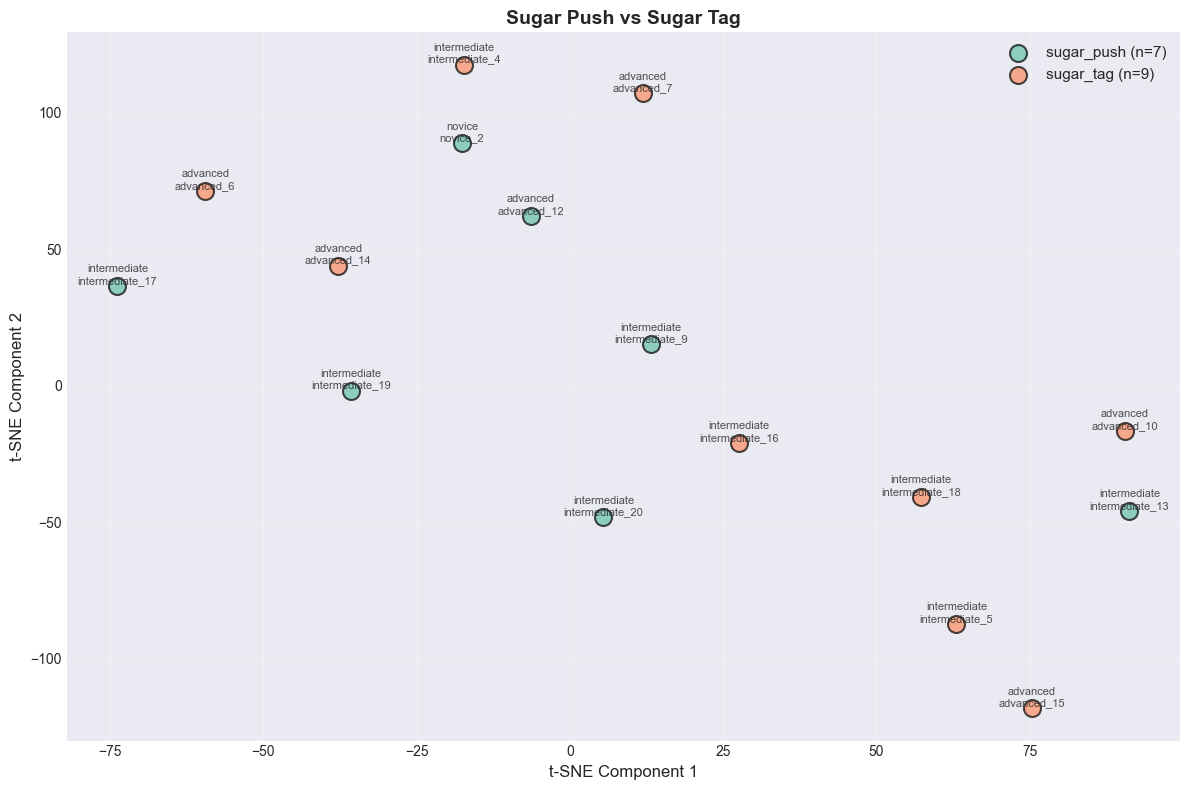

In [174]:
# plot by trick label
plt.figure(figsize=(12, 8))
unique_labels = np.unique(y)
colors = sns.color_palette('Set2', n_colors=len(unique_labels))
label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

for label in unique_labels:
    mask = y == label
    indices = np.where(mask)[0]
    
    plt.scatter(
        emb_plot[mask, 0],
        emb_plot[mask, 1],
        label=f'{label} (n={mask.sum()})',
        s=150,
        alpha=0.7,
        color=label_to_color[label],
        edgecolors='black',
        linewidth=1.5
    )
    
    for idx in indices:
        division = meta.iloc[idx]['division']
        video = meta.iloc[idx]['video']
        plt.annotate(
            f"{division}\n{video}",
            (emb_plot[idx, 0], emb_plot[idx, 1]),
            fontsize=8,
            alpha=0.8,
            ha='center',
            va='bottom'
        )

plt.xlabel(f'{method} Component 1', fontsize=12)
plt.ylabel(f'{method} Component 2', fontsize=12)
plt.title('Sugar Push vs Sugar Tag', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization 2: KMeans Clustering

In [179]:
# run kmeans
models, ks, inertias, sils = clustering_kmeans(Xs, k_range=range(2, min(len(df), 9)))
best_k = 2 # ks[int(np.nanargmax(sils))]
print(f'Best K by silhouette: {best_k}')

km = models[best_k]
labels = km.predict(Xs)

Best K by silhouette: 2


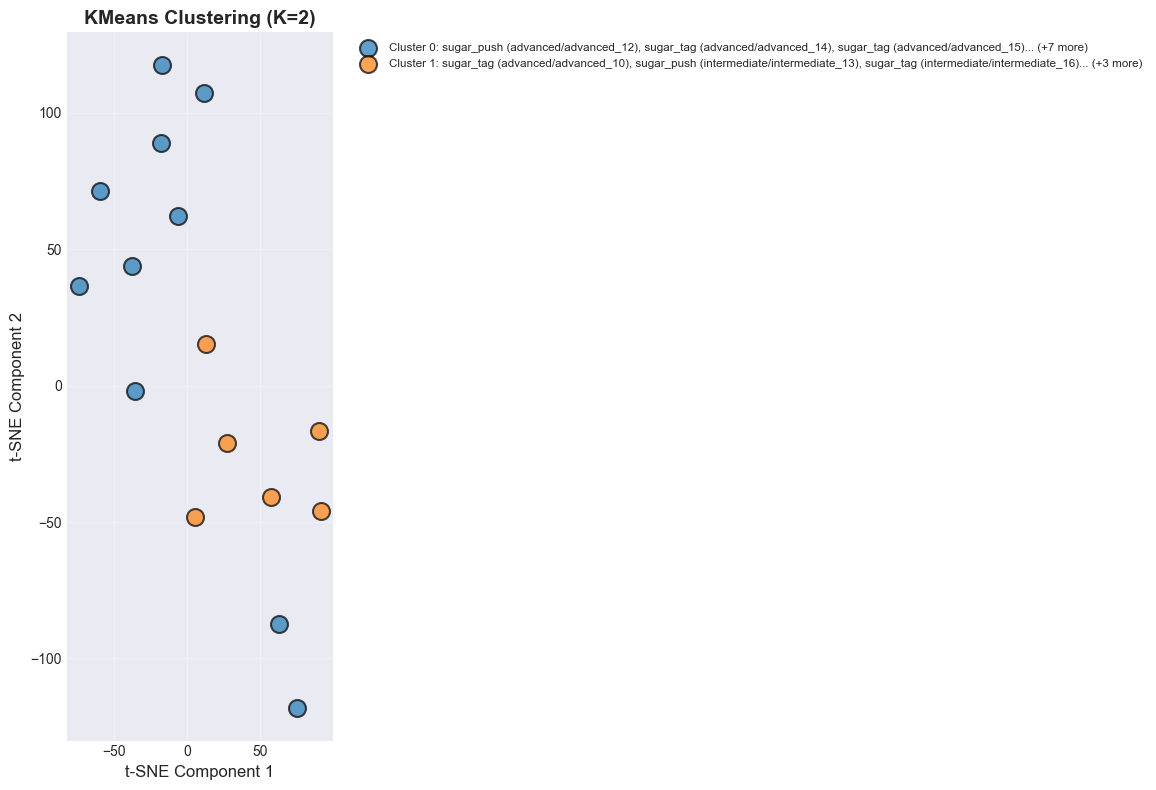

In [180]:
# plot clusters
plt.figure(figsize=(12, 8))
palette = sns.color_palette('tab10', n_colors=len(np.unique(labels)))
cluster_to_indices = {cl: np.where(labels == cl)[0] for cl in np.unique(labels)}

for i, cl in enumerate(np.unique(labels)):
    idxs = cluster_to_indices[cl]
    vids = [f"{meta.iloc[idx]['label']} ({meta.iloc[idx]['division']}/{meta.iloc[idx]['video']})" for idx in idxs]
    
    if len(vids) > 3:
        legend_label = f"Cluster {cl}: {', '.join(vids[:3])}... (+{len(vids)-3} more)"
    else:
        legend_label = f"Cluster {cl}: {', '.join(vids)}"
    
    plt.scatter(emb_plot[idxs, 0], emb_plot[idxs, 1], label=legend_label, 
               s=150, alpha=0.7, color=palette[i % len(palette)], 
               edgecolors='black', linewidth=1.5)

plt.xlabel(f'{method} Component 1', fontsize=12)
plt.ylabel(f'{method} Component 2', fontsize=12)
plt.title(f'KMeans Clustering (K={best_k})', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Output a Model

In [181]:
best_k = 2
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10, random_state=0)),
    ("kmeans", KMeans(n_clusters=best_k, random_state=0)    )
])

pipe.fit(X)

# save model
joblib.dump(pipe, OUT_DIR / 'kmeans.joblib')

['../data/processed/kmeans.joblib']

## Predict

In [183]:
# Load saved model components
pipe = joblib.load(Path("../data/processed/kmeans.joblib"))

# Load new video
seq = load_keypoints("../data/keypoints_2/advanced/advanced_9/keypoints.npy")
vec = aggregate_video_features(seq, target_len=64)

# Predict
cluster_id = pipe.predict([vec])[0]

# Print cluster label
if cluster_id == 0:
    print("Video belongs to sugar tag cluster")
else:
    print("Video belongs to sugar push cluster")

Video belongs to sugar tag cluster
